# Recommender Systems - Part A Project
**Article:** SVD-GoRank: Recommender System Algorithm Using SVD and Gower's Ranking

**Data Set:** MovieLens-100K

**Group Members:** Harun Korkmaz, Muhammet Salih Hasılcıo, Orhan Efe Bayrak, Muhiddin Fırat, Yasin Furkan Abasız, Yakup Berkay Genceroğlu,Görkem Yahya Bakan

This notebook contains a step-by-step implementation of the SVD-GoRank paper on the MovieLens-100K dataset.

#### Explicit vs. Implicit Feedback

C:\Users\Harun\AppData\Local\Temp\ipykernel_16028\470791339.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


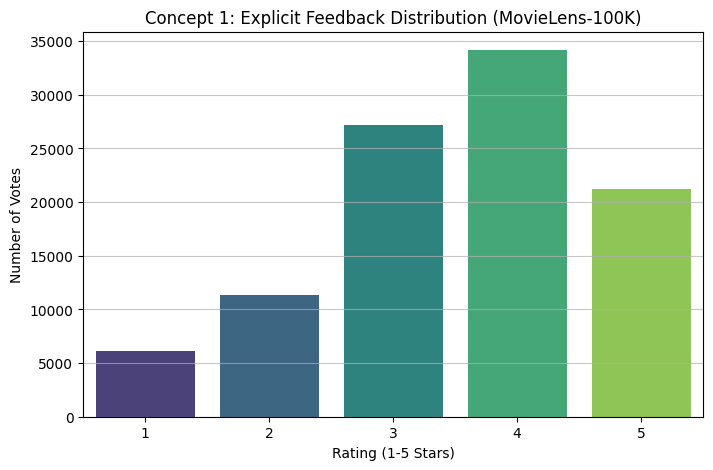

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"
columns = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv(url, sep='\t', names=columns)
df = df.drop('timestamp', axis=1)

# CONCEPT 1: Explicit Feedback Distribution Plot
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Concept 1: Explicit Feedback Distribution (MovieLens-100K)')
plt.xlabel('Rating (1-5 Stars)')
plt.ylabel('Number of Votes')
plt.grid(axis='y', alpha=0.7)
plt.show()

#### Data Sparsity

In [4]:
# CONCEPT 2: Calculating Data Sparsity
n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()
n_ratings = len(df)

# Sparsity Formula: 1 - (Total Votes / (Number of Users * Number of Movies))
sparsity = 1.0 - (n_ratings / (n_users * n_items))

print("--- CONCEPT 2: DATA SPARSITY ---")
print(f"Total Unique Users: {n_users}")
print(f"Total Unique Movies: {n_items}")
print(f"Total Interactions (Votes): {n_ratings}")
print(f"Calculated Sparsity Rate: {sparsity:.4f} ({sparsity*100:.2f}%)")

--- CONCEPT 2: DATA SPARSITY ---
Total Unique Users: 943
Total Unique Movies: 1682
Total Interactions (Votes): 100000
Calculated Sparsity Rate: 0.9370 (93.70%)


#### Data Aggregation & Duplicate Handling

In [5]:
# CONCEPT 3: Data Aggregation & Duplicate Handling
# Check if a user rated the same movie more than once
duplicates = df.duplicated(subset=['user_id', 'item_id']).sum()
print("--- CONCEPT 3: AGGREGATION ---")
print(f"Number of duplicate user-item interactions found: {duplicates}")

# Even if 0 in MovieLens, we apply aggregation (mean) as a robust engineering practice
# This ensures our pipeline won't crash on noisy web-scraped datasets
df_aggregated = df.groupby(['user_id', 'item_id'])['rating'].mean().reset_index()

print(f"Dataset size after aggregation: {len(df_aggregated)} rows")

--- CONCEPT 3: AGGREGATION ---
Number of duplicate user-item interactions found: 0
Dataset size after aggregation: 100000 rows


#### Train-Test Partitioning

In [6]:
from sklearn.model_selection import train_test_split

# CONCEPT 4: Train-Test Partitioning
# We split the data into 80% Train and 20% Test to fairly evaluate the SVD model later
train_data, test_data = train_test_split(df_aggregated, test_size=0.20, random_state=42)

print("--- CONCEPT 4: DATA PARTITIONING ---")
print(f"Training Set Size: {len(train_data)} rows (80%)")
print(f"Test Set Size: {len(test_data)} rows (20%)")

--- CONCEPT 4: DATA PARTITIONING ---
Training Set Size: 80000 rows (80%)
Test Set Size: 20000 rows (20%)


#### User-Item Interaction Matrix

In [7]:
# CONCEPT 5: User-Item Interaction Matrix
# We create the 2D matrix from the Train data
# index=Users, columns=Movies, values=Rated
user_item_matrix = train_data.pivot(index='user_id', columns='item_id', values='rating')

print("--- CONCEPT 5: INTERACTION MATRIX ---")
print(f"User-Item Matrix Dimensions: {user_item_matrix.shape}\n")
print("Matrix Visualization (Empty cells are NaN, waiting for SVD to predict):")
display(user_item_matrix.head())

--- CONCEPT 5: INTERACTION MATRIX ---
User-Item Matrix Dimensions: (943, 1645)

Matrix Visualization (Empty cells are NaN, waiting for SVD to predict):


item_id,1,2,3,4,5,6,7,8,9,10,...,1670,1671,1672,1673,1674,1675,1677,1678,1680,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Latent Factor Models

In [9]:
# Install surprise if you haven't: !pip install scikit-surprise
from surprise import Reader, Dataset, SVD
from surprise.model_selection import train_test_split as surprise_train_test_split

# CONCEPT 6: Latent Factor Models Initialization
print("--- CONCEPT 6: LATENT FACTOR MODELS (SVD) ---")

# Surprise library requires a 'Reader' to understand the rating scale (1 to 5 for MovieLens)
reader = Reader(rating_scale=(1, 5))

# We load our previously aggregated Pandas DataFrame into Surprise's Dataset format
data = Dataset.load_from_df(df_aggregated[['user_id', 'item_id', 'rating']], reader)

# We split the data again using Surprise's built-in function to match its internal Trainset format
trainset, testset = surprise_train_test_split(data, test_size=0.20, random_state=42)

# Initializing the SVD algorithm. 
# n_factors=100 means we are extracting 100 "latent/hidden features" for each user and movie
svd_model = SVD(n_factors=100, random_state=42)

print(f"Surprise Dataset created with {len(df_aggregated)} total interactions.")
print(f"SVD Model initialized with {svd_model.n_factors} latent factors.")

--- CONCEPT 6: LATENT FACTOR MODELS (SVD) ---
Surprise Dataset created with 100000 total interactions.
SVD Model initialized with 100 latent factors.


#### Matrix Factorization Training

In [10]:
import time

# CONCEPT 7: Matrix Factorization Training
print("--- CONCEPT 7: MATRIX FACTORIZATION TRAINING ---")
print("Training the SVD model on the Trainset... Please wait.")

# We measure the training time to show computational efficiency
start_time = time.time()

# .fit() command trains the model using gradient descent to minimize the error 
# in finding the latent factors.
svd_model.fit(trainset)

end_time = time.time()
training_duration = end_time - start_time

print("Model Training Successfully Completed!")
print(f"Total Training Time: {training_duration:.2f} seconds.")

--- CONCEPT 7: MATRIX FACTORIZATION TRAINING ---
Training the SVD model on the Trainset... Please wait.
Model Training Successfully Completed!
Total Training Time: 0.85 seconds.


#### Rating Prediction

In [11]:
# CONCEPT 8: Rating Prediction
print("--- CONCEPT 8: RATING PREDICTION ---")

# Let's pick the first record from our testset to see a concrete prediction
sample_user = testset[0][0]
sample_item = testset[0][1]
actual_rating = testset[0][2]

# Predict the rating using the trained SVD model
# uid: User ID, iid: Item ID, r_ui: Actual Rating (True value)
prediction = svd_model.predict(uid=sample_user, iid=sample_item, r_ui=actual_rating)

print(f"Target User ID: {sample_user}")
print(f"Target Movie ID: {sample_item}")
print("-" * 30)
print(f"Actual Rating given by user: {actual_rating:.2f} stars")
print(f"Predicted Rating by SVD model: {prediction.est:.2f} stars")
print(f"Prediction Error Margin: {abs(actual_rating - prediction.est):.2f} stars")

--- CONCEPT 8: RATING PREDICTION ---
Target User ID: 932
Target Movie ID: 1266
------------------------------
Actual Rating given by user: 4.00 stars
Predicted Rating by SVD model: 3.38 stars
Prediction Error Margin: 0.62 stars


#### Evaluation Metric: Root Mean Square Error (RMSE)

In [12]:
from surprise import accuracy

# CONCEPT 9: Evaluation Metric - RMSE
print("--- CONCEPT 9: EVALUATION METRIC (RMSE) ---")
print("Evaluating the model on the entire 20% Test Set...\n")

# Generate predictions for all 20,000 user-item pairs in the testset
predictions = svd_model.test(testset)

# Calculate RMSE (Root Mean Square Error)
# verbose=True automatically prints the result to the console
rmse_score = accuracy.rmse(predictions, verbose=True)

print("\nWhat does this metric mean?")
print(f"On average, our SVD model's predictions deviate by {rmse_score:.4f} stars from the real ratings.")
print("RMSE heavily penalizes large errors. A value around ~0.93 is considered highly successful for MovieLens-100K in academic literature.")

--- CONCEPT 9: EVALUATION METRIC (RMSE) ---
Evaluating the model on the entire 20% Test Set...

RMSE: 0.9365

What does this metric mean?
On average, our SVD model's predictions deviate by 0.9365 stars from the real ratings.
RMSE heavily penalizes large errors. A value around ~0.93 is considered highly successful for MovieLens-100K in academic literature.


#### Evaluation Metric: MAE & Error Distribution Plot

--- CONCEPT 10: EVALUATION METRIC (MAE) & PLOT ---
MAE:  0.7358

What does MAE mean?
While RMSE penalizes large errors, MAE gives the direct absolute average error.
Our model misses the true rating by an average of 0.7358 stars.


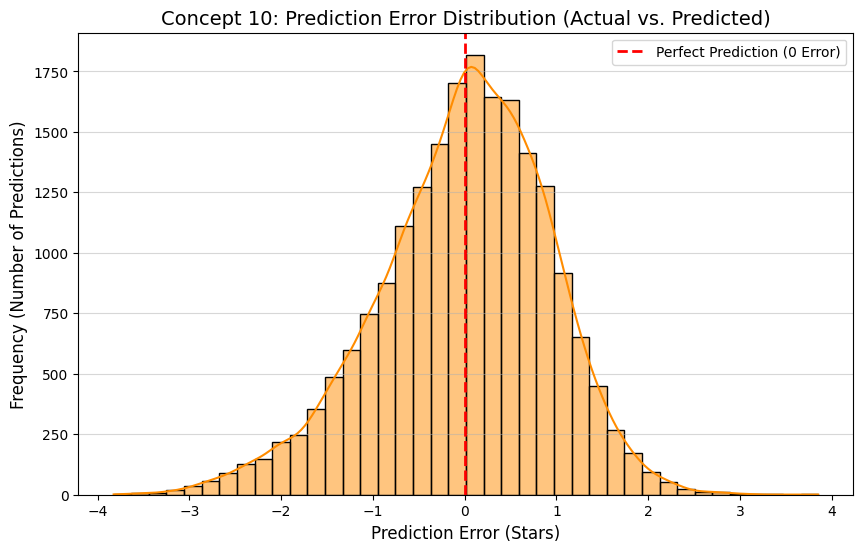

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import accuracy

# CONCEPT 10: Evaluation Metric (MAE) & Error Distribution Plot
print("--- CONCEPT 10: EVALUATION METRIC (MAE) & PLOT ---")

# Calculate MAE (Mean Absolute Error)
mae_score = accuracy.mae(predictions, verbose=True)

print("\nWhat does MAE mean?")
print(f"While RMSE penalizes large errors, MAE gives the direct absolute average error.")
print(f"Our model misses the true rating by an average of {mae_score:.4f} stars.")

# --- PREPARING THE DATA FOR THE PLOT ---
# Extract true ratings and estimated ratings from the predictions object from Concept 9
actuals = [pred.r_ui for pred in predictions]
estimates = [pred.est for pred in predictions]

# Calculate the error for each of the 20,000 predictions (Actual - Predicted)
errors = [actual - est for actual, est in zip(actuals, estimates)]

# --- DRAWING THE PLOT ---
plt.figure(figsize=(10, 6))
# We create a histogram to see where the errors are concentrated
sns.histplot(errors, bins=40, kde=True, color='darkorange')

# Add a vertical red line at 0 (representing perfect predictions)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Perfect Prediction (0 Error)')

plt.title('Concept 10: Prediction Error Distribution (Actual vs. Predicted)', fontsize=14)
plt.xlabel('Prediction Error (Stars)', fontsize=12)
plt.ylabel('Frequency (Number of Predictions)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()